In [1]:
import pandas as pd
import seaborn as srn
import statistics as sts

In [2]:
dataset = pd.read_csv('Churn.csv', sep= ";")

dataset.head()

,X0,X1,X2,X3,X4,X4.1,X6,X7,X8,X9,X10,X11
0,1,619,RS,Feminino,42,2,0,1,1,1,10134888.0,1
1,2,608,SC,Feminino,41,1,8380786,1,0,1,11254258.0,0
2,3,502,RS,Feminino,42,8,1596608,3,1,0,11393157.0,1
3,4,699,RS,Feminino,39,1,0,2,0,0,9382663.0,0
4,5,850,SC,Feminino,43,2,12551082,1,1,1,790841.0,0


In [3]:
dataset.shape

(999, 12)

In [4]:
# Problema encontrado: Falta de nome nas colunas
dataset.columns = ["Id", "Score", "Estado", "Genero", "Idade", "Patrimonio", "Saldo", "Produtos", "TemCartCredito", "Ativo", "Salario",
                   "Saiu"]

In [5]:
dataset.head()

# 0 e 1 em tabelas geralmente são true e false

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
0,1,619,RS,Feminino,42,2,0,1,1,1,10134888.0,1
1,2,608,SC,Feminino,41,1,8380786,1,0,1,11254258.0,0
2,3,502,RS,Feminino,42,8,1596608,3,1,0,11393157.0,1
3,4,699,RS,Feminino,39,1,0,2,0,0,9382663.0,0
4,5,850,SC,Feminino,43,2,12551082,1,1,1,790841.0,0


# Inicio da analise exploratoria

In [6]:
agrupado = dataset.groupby(["Estado"]).size()
agrupado

Estado
PR    257
RP      1
RS    478
SC    258
SP      4
TD      1
dtype: int64

<Axes: xlabel='Estado'>

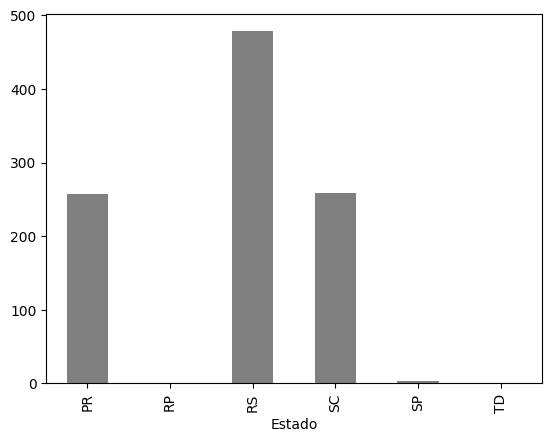

In [7]:
agrupado.plot.bar(color='gray')

In [8]:
agrupado = dataset.groupby(['Genero']).size()
agrupado

Genero
F              2
Fem            1
Feminino     461
M              6
Masculino    521
dtype: int64

<Axes: xlabel='Genero'>

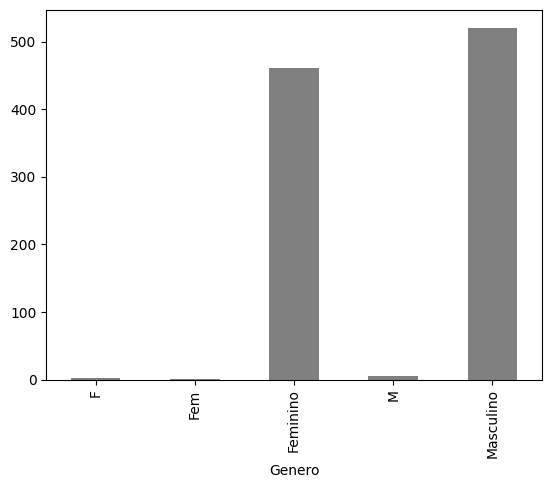

In [9]:
agrupado.plot.bar(color="gray")

In [10]:
# Acima foi a exploranção de dados Qualitativos

# Agora comeraça a ver dados quantitativos
dataset['Score'].describe()

count    999.000000
mean     648.621622
std       98.264219
min      376.000000
25%      580.000000
50%      653.000000
75%      721.000000
max      850.000000
Name: Score, dtype: float64

Text(0.5, 1.0, 'Score')

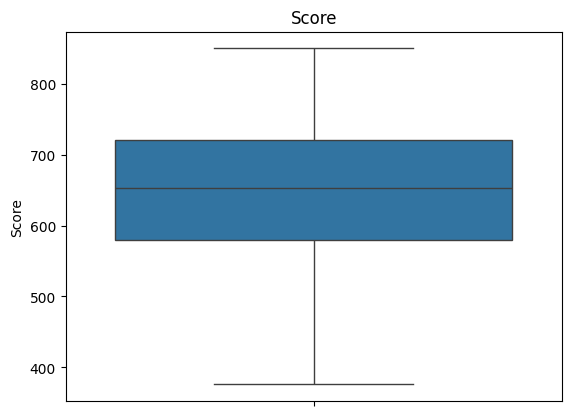

In [11]:
srn.boxplot(dataset['Score']).set_title('Score')

Text(0.5, 1.0, 'Score')

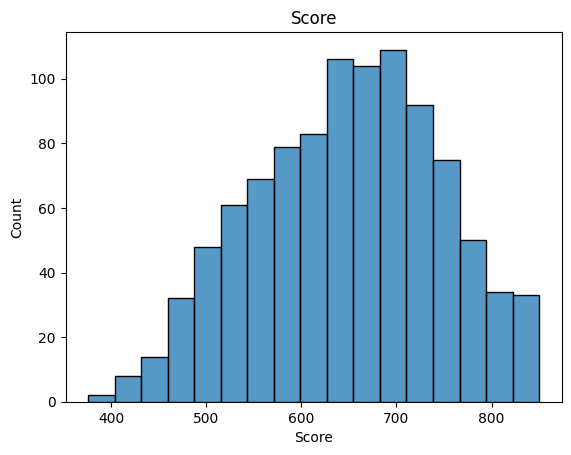

In [12]:
srn.histplot(dataset['Score']).set_title('Score')

In [13]:
dataset['Idade'].describe()

count    999.000000
mean      38.902903
std       11.401912
min      -20.000000
25%       32.000000
50%       37.000000
75%       44.000000
max      140.000000
Name: Idade, dtype: float64

Text(0.5, 1.0, 'Idade')

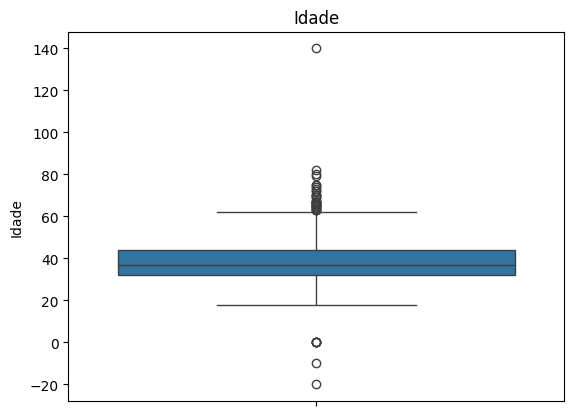

In [14]:
srn.boxplot(dataset['Idade']).set_title('Idade')

Text(0.5, 1.0, 'Idade')

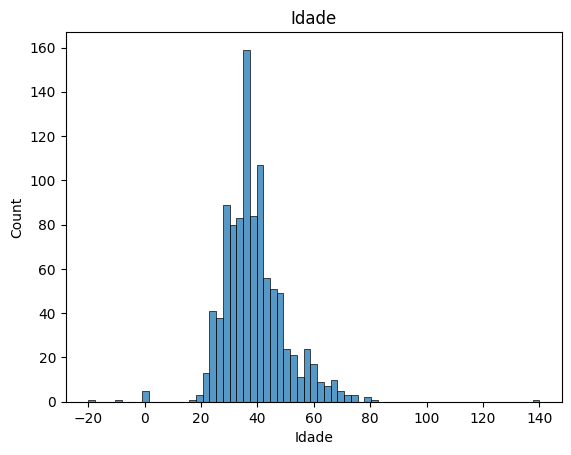

In [15]:
srn.histplot(dataset['Idade']).set_title('Idade')

Ja da para ver que se tem problema nos dados de idade, pois há idades que estão negativas e maiores que cem, o que não é possivel e por isso está errado.

In [16]:
dataset["Saldo"].describe()

count    9.990000e+02
mean     7.164928e+06
std      6.311840e+06
min      0.000000e+00
25%      0.000000e+00
50%      8.958835e+06
75%      1.258684e+07
max      2.117743e+07
Name: Saldo, dtype: float64

Text(0.5, 1.0, 'Saldo')

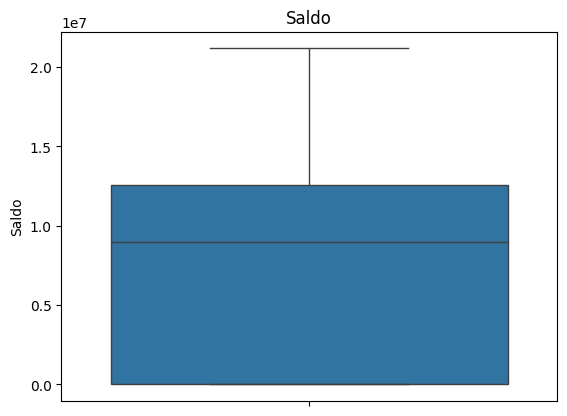

In [17]:
srn.boxplot(dataset["Saldo"]).set_title("Saldo")

Text(0.5, 1.0, 'Saldo')

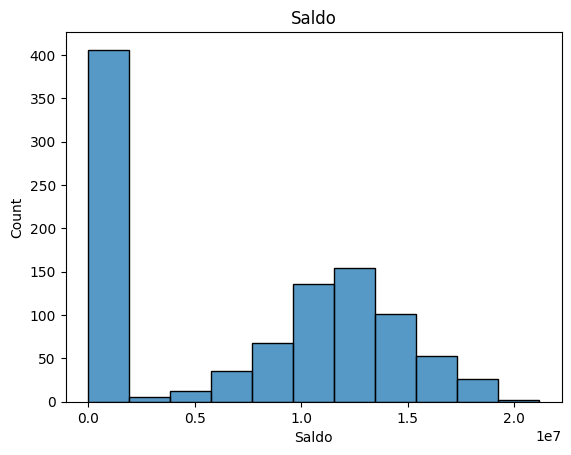

In [18]:
srn.histplot(dataset["Saldo"]).set_title("Saldo")

In [19]:
dataset["Salario"].describe()

count    9.920000e+02
mean     3.528762e+07
std      5.305800e+08
min      9.677000e+03
25%      3.029011e+06
50%      8.703250e+06
75%      1.405213e+07
max      1.193469e+10
Name: Salario, dtype: float64

Text(0.5, 1.0, 'Salario')

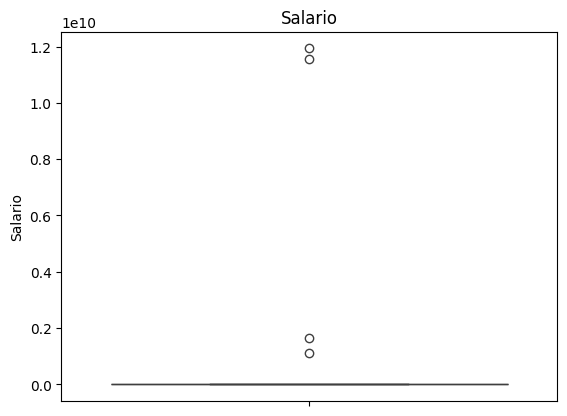

In [20]:
srn.boxplot(dataset["Salario"]).set_title("Salario")

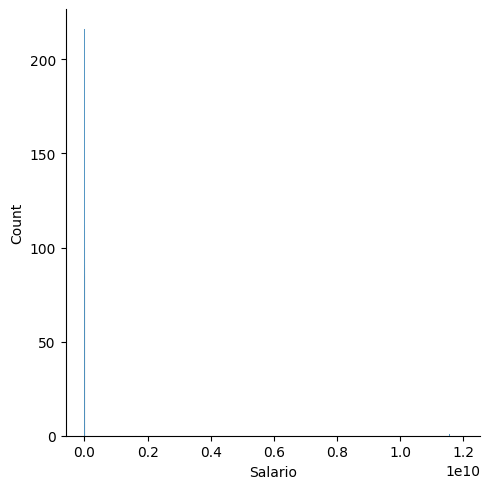

In [21]:
srn.displot(dataset["Salario"])

In [22]:
dataset.isnull().sum()

Id                0
Score             0
Estado            0
Genero            8
Idade             0
Patrimonio        0
Saldo             0
Produtos          0
TemCartCredito    0
Ativo             0
Salario           7
Saiu              0
dtype: int64

# Tratamento de dados

In [26]:
# Resolvendo o problema de valores NULOS na coluna de salarios

dataset["Salario"].describe()

count    9.920000e+02
mean     3.528762e+07
std      5.305800e+08
min      9.677000e+03
25%      3.029011e+06
50%      8.703250e+06
75%      1.405213e+07
max      1.193469e+10
Name: Salario, dtype: float64

In [27]:
mediana = sts.median(dataset["Salario"])
mediana

70518.0

In [28]:
# Subistituindo valores NAN (Nulos) pela mediana
dataset["Salario"].fillna(mediana, inplace=True)

In [32]:
# Verificar se NAN não existem mais
dataset["Salario"].isnull().sum()


np.int64(0)

In [34]:
# genero, problemas de valores nulos e nomes errados (Sâo dados categoricos)

agrupado = dataset.groupby(["Genero"]).size()
agrupado

Genero
F              2
Fem            1
Feminino     461
M              6
Masculino    521
dtype: int64

In [35]:
dataset["Genero"].isnull().sum()

np.int64(8)

In [36]:
# preencher os nulos pela moda, no caso o masculino

dataset["Genero"].fillna("Masculino", inplace=True)

In [37]:
dataset["Genero"].isnull().sum()

np.int64(0)

In [ ]:
# Padroniza de acordo com o dominio
dataset.loc[dataset['Genero'] == "M", "Genero"] = "Masculino"
dataset.loc[dataset['Genero'].isin( ['Fem', 'F'] ), "Genero"] = "Feminino"

#Visualiza o resultado
agrupado = dataset.groupby(["Genero"]).size()
agrupado

Genero
Feminino     464
Masculino    535
dtype: int64

In [ ]:
# Mechendo com idades, problemas encontrados: Idades negativas, idades maiores que 120(Criterio definido)
dataset["Idade"].describe()

count    999.000000
mean      38.902903
std       11.401912
min      -20.000000
25%       32.000000
50%       37.000000
75%       44.000000
max      140.000000
Name: Idade, dtype: float64

In [43]:
# Visualizar quantos registros estão fora dessa encrenca

dataset.loc[(dataset["Idade"] < 0) | (dataset["Idade"] > 120) ]

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
867,869,636,RS,Feminino,-10,1,17083346,1,1,0,11051028.0,1
984,986,773,RS,Masculino,-20,1,12453278,2,0,1,1172357.0,0
990,992,655,RS,Masculino,140,5,93147,2,1,0,6621413.0,0


In [45]:
# Como não são dados categoricos deve-se substituir pela mediana

mediana = sts.median(dataset["Idade"])
mediana

37

In [47]:
# Substituição
dataset.loc[(dataset["Idade"] < 0) | (dataset["Idade"] > 120) , "Idade"] = mediana

In [55]:
# Verificamos se ainda existem idades foras do dominio
dataset.loc[(dataset["Idade"] < 0) | (dataset["Idade"] > 120) ]

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu


In [56]:
# Dados duplicados buscamos pelo ID
dataset[dataset.duplicated(["Id"], keep=False)]


,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
80,81,665,RS,Feminino,34,1,9664554,2,0,0,17141366.0,0
81,81,665,RS,Feminino,34,1,9664554,2,0,0,17141366.0,0


In [58]:
# Escluimos os duplicados
dataset.drop_duplicates(subset="Id", keep="first", inplace=True)

# buscamos duplicados
dataset[dataset.duplicated(["Id"], keep=False)]

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu


In [61]:
# Arrumando o problema de estados fora do dominio
agrupado = dataset.groupby(["Estado"]).size()
agrupado

Estado
PR    257
RP      1
RS    477
SC    258
SP      4
TD      1
dtype: int64

In [63]:
# Atribuimos RS (moda)
dataset.loc[dataset['Estado'].isin( ['SP', 'TD', 'RP'] ), "Estado"] = "RS"
agrupado = dataset.groupby(["Estado"]).size()

In [64]:
# Verificamos o resultado
agrupado

Estado
PR    257
RS    483
SC    258
dtype: int64

In [66]:
# Por ultimo tratamento de outliers em salario, vamos considerar 2 desvios padrão
desv = sts.stdev(dataset["Salario"])
desv

528988918.4679201

In [72]:
# definir padrão como maior que 2 desvios padrão
# checamos se algum atende o criterio
dataset.loc[dataset["Salario"] >= 2 * desv]

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
7,8,376,PR,Feminino,29,4,11504674,4,1,0,1.193469e+10,1
116,118,668,PR,Feminino,37,6,1678644,1,1,0,1.156383e+10,0
170,172,484,RS,Feminino,29,4,13011439,1,1,0,1.640179e+09,0
230,232,673,RS,Masculino,72,1,0,2,0,1,1.119812e+09,0


In [ ]:
# Vamos atualizar salarios para mediana, calculamos
mediana = sts.median(dataset["Salario"])
mediana

8637195.5

In [74]:
# atribuimos 
dataset.loc[dataset["Salario"] >= 2 * desv, "Salario"] = mediana

# checamos se algum atende o criterio
dataset.loc[dataset["Salario"] >= 2 * desv ]

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
